# 01 — EDA: target, coverage, age curves (SPEC definition)

**Unit:** one player on 1 September each year (2013–2024), in the 7 SPEC leagues, with ≥ 450 league minutes the previous season.
**Target:** `log(value as of next 1 Sep / value as of 1 Sep)`, each the latest valuation on or before that date, kept only if the player was revalued in between.

Values are Transfermarkt crowd estimates, not transfer fees. This notebook uses the same `build_snapshots` / `build_features` code as training. It covers every snapshot year, including the test years, so it is **descriptive only**: no modelling choice is made from the 2023–2024 rows here.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scout.data.raw import read_raw
from scout.data.snapshots import build_snapshots
from scout.ml.features import build_features

BLUE, INK, MUTED, GRID = "#2a78d6", "#0b0b0b", "#52514e", "#e6e5e0"
plt.rcParams.update({
    "figure.figsize": (9, 4), "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.titleweight": "bold", "axes.titlelocation": "left",
})

raw = read_raw()
s = build_snapshots(raw)
t = s[s.target.notna()]
t = pd.concat([t.drop(columns=["league"]), build_features(t, raw)], axis=1)
print(f"{len(s):,} population snapshots, {len(t):,} with a target ({len(t) / len(s):.1%})")

28,260 population snapshots, 27,330 with a target (96.7%)


## 1. Target distribution

In [2]:
print(t.target.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(3).to_string())
share = pd.Series({"rise": (t.target > 0).mean(), "no change": (t.target == 0).mean(), "fall": (t.target < 0).mean()})
print()
print(share.map("{:.1%}".format).to_string())

count    27330.000
mean        -0.101
std          0.529
min         -2.639
1%          -1.386
5%          -0.916
25%         -0.405
50%         -0.134
75%          0.163
95%          0.836
99%          1.482
max          4.382

rise         30.4%
no change    14.6%
fall         55.1%


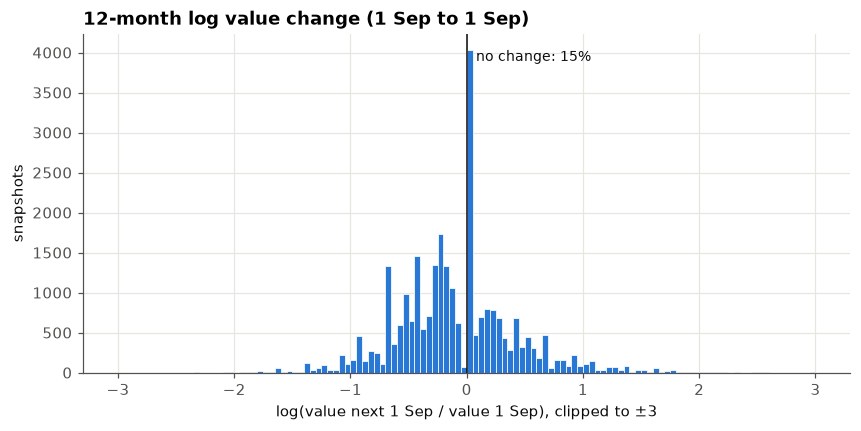

In [3]:
fig, ax = plt.subplots()
ax.hist(t.target.clip(-3, 3), bins=np.linspace(-3, 3, 121), color=BLUE, edgecolor="white", linewidth=0.5)
ax.axvline(0, color=INK, linewidth=1)
ax.set(title="12-month log value change (1 Sep to 1 Sep)", xlabel="log(value next 1 Sep / value 1 Sep), clipped to ±3", ylabel="snapshots")
ax.text(0.08, 0.92, f"no change: {share['no change']:.0%}", color=INK, fontsize=9, transform=ax.get_xaxis_transform())
plt.show()

## 2. Coverage by league and year

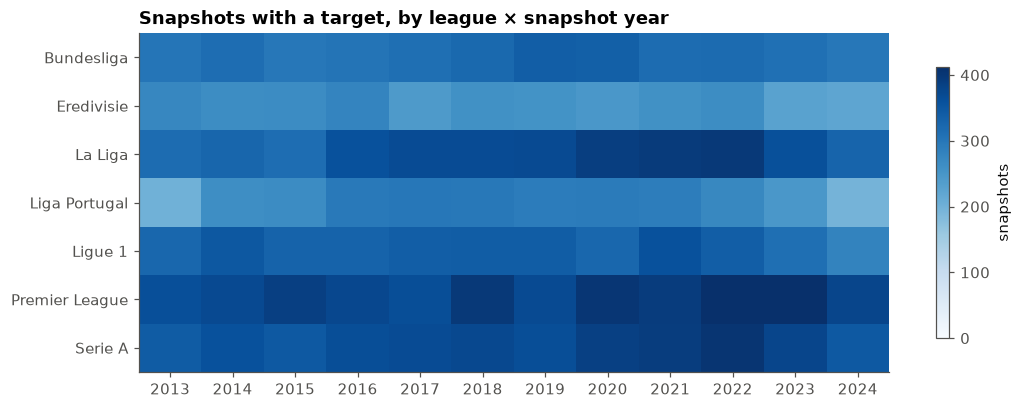

year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
league,,,,,,,,,,,,
Bundesliga,301,314,298,303,312,321,338,335,316,318,309,298
Eredivisie,274,264,266,278,243,259,255,247,259,265,228,221
La Liga,317,326,314,360,368,367,370,389,393,397,361,329
Liga Portugal,201,263,267,296,298,297,291,292,289,273,247,196
Ligue 1,324,349,331,331,339,341,340,324,359,338,311,279
Premier League,363,371,387,374,364,397,369,401,392,412,412,378
Serie A,342,359,347,365,368,372,364,386,390,403,378,347


In [4]:
names = {"GB1": "Premier League", "ES1": "La Liga", "L1": "Bundesliga", "IT1": "Serie A", "FR1": "Ligue 1",
         "NL1": "Eredivisie", "PO1": "Liga Portugal"}
cov = pd.crosstab(t.league.map(names), t.year)
fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(cov.values, cmap="Blues", aspect="auto", vmin=0)
ax.set_xticks(range(cov.shape[1]), cov.columns); ax.set_yticks(range(cov.shape[0]), cov.index)
ax.grid(False); ax.set_title("Snapshots with a target, by league × snapshot year")
fig.colorbar(im, ax=ax, label="snapshots", shrink=0.8)
plt.show()
cov

In [5]:
by_year = t.groupby("year").target.agg(["size", "mean", "median", lambda x: (x == 0).mean()])
by_year.columns = ["n", "mean", "median", "share unchanged"]
by_year.round(3)

,n,mean,median,share unchanged
year,,,,
2013,2122,-0.117,-0.118,0.158
2014,2246,-0.114,-0.105,0.173
2015,2210,-0.060,0.000,0.191
2016,2307,-0.066,0.000,0.204
2017,2292,0.032,0.000,0.167
2018,2354,-0.008,0.000,0.198
2019,2327,-0.241,-0.223,0.053
2020,2374,-0.130,-0.134,0.086
2021,2398,-0.171,-0.182,0.132


## 3. Value curves by age

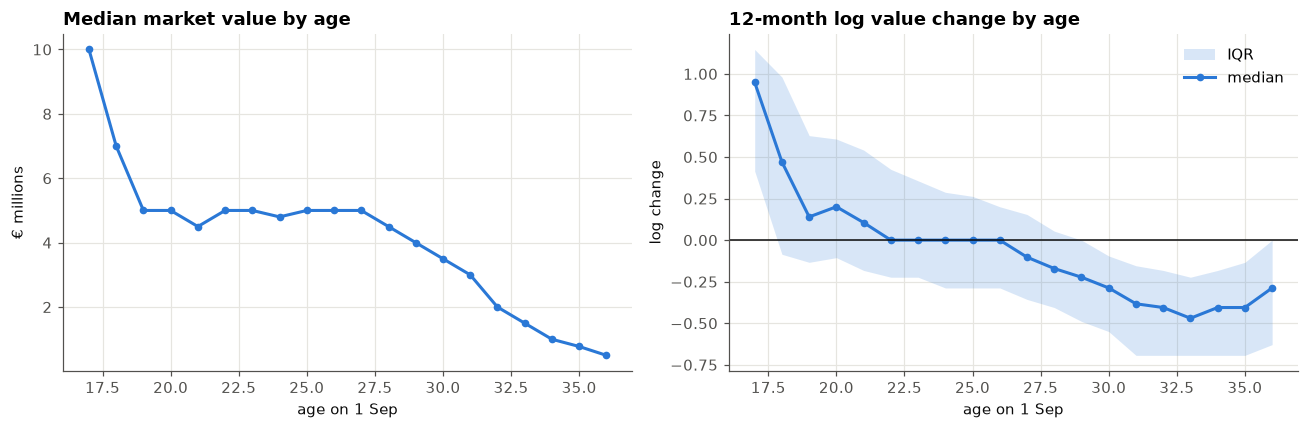

,median_value,n,q25,median_target,q75,mean_target
age_bin,,,,,,
17,10000000.0,10,0.415,0.949,1.147,0.853
18,7000000.0,119,-0.085,0.470,0.981,0.479
19,5000000.0,382,-0.134,0.140,0.629,0.282
20,5000000.0,780,-0.105,0.201,0.608,0.306
21,4500000.0,1360,-0.182,0.105,0.542,0.215
22,5000000.0,1856,-0.223,0.000,0.426,0.136
23,5000000.0,2147,-0.223,0.000,0.357,0.080
24,4800000.0,2421,-0.288,0.000,0.288,0.030
25,5000000.0,2524,-0.288,0.000,0.263,-0.002


In [6]:
a = t[t.age.between(17, 37)].assign(age_bin=lambda d: d.age.astype(int))
by_age = a.groupby("age_bin").agg(median_value=("value_now", "median"), n=("target", "size"),
                                  q25=("target", lambda s: s.quantile(.25)), median_target=("target", "median"),
                                  q75=("target", lambda s: s.quantile(.75)), mean_target=("target", "mean"))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(by_age.index, by_age.median_value / 1e6, color=BLUE, linewidth=2, marker="o", markersize=4)
ax1.set(title="Median market value by age", xlabel="age on 1 Sep", ylabel="€ millions")
ax2.fill_between(by_age.index, by_age.q25, by_age.q75, color=BLUE, alpha=0.18, linewidth=0, label="IQR")
ax2.plot(by_age.index, by_age.median_target, color=BLUE, linewidth=2, marker="o", markersize=4, label="median")
ax2.axhline(0, color=INK, linewidth=1)
ax2.set(title="12-month log value change by age", xlabel="age on 1 Sep", ylabel="log change")
ax2.legend(frameon=False)
plt.tight_layout(); plt.show()
by_age.round(3)

## Findings

- **Coverage:** 27,330 of 28,260 population snapshots (96.7%) have a target; each league contributes a steady 200–410 per year.
- **Target shape:** established first-team players lose value more often than they gain it: 55% fall, 30% rise, 15% unchanged, median −0.13. This differs from v0 (all players, any valuation date: median 0, mean +0.12). The population is older and already valued, and prospects without 450 league minutes are excluded.
- **2019 snapshots** (target measured in Sept 2020) have mean −0.24 and only 5% unchanged: the COVID market-wide markdown. Any model is judged per year for this reason.
- **Age still dominates:** median change is positive up to about 21, zero from 22 to 26, and about −0.4 from 31 to 35. Median value is flat at about €5m from 19 to 26, then falls.
- **Descriptive only:** this notebook includes the test years for coverage; no modelling decision is taken from them.